# Pipeline de clasificación

El objetivo del presente pipeline es **clasificar cada cromosoma segmentado en su tipo correspondiente**: los 22 autosomas (1 a 22) y los dos cromosomas sexuales (X e Y), es decir, 24 clases en total. Constituye la última etapa del flujo de cariotipado: recibe los cromosomas individuales que produce la segmentación y les asigna una etiqueta, permitiendo luego ensamblar el cariograma final.

El problema se aborda mediante *transfer learning*: se parte de redes convolucionales preentrenadas en ImageNet y se las ajusta (*fine-tuning*) a nuestro dominio.

In [ ]:
import json
import os
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# Dataset: recortes individuales de cromosomas

Para entrenar el clasificador se necesita un conjunto donde cada muestra sea un **único cromosoma** etiquetado con su clase. Estos recortes se generan a partir del dataset **AutoKary2022**, que provee las imágenes de cariotipo junto con las máscaras poligonales de cada cromosoma (anotaciones en formato LabelMe, un archivo `.json` por imagen).

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Condicionamiento del dataset

A partir de cada imagen de cariotipo y sus anotaciones, se extrae cada cromosoma de forma individual. Por cada uno se lo **aísla** del fondo con su máscara, se lo **rectifica** a una orientación canónica (vertical) y se lo **escala** a un tamaño fijo de 224×224 píxeles —el tamaño de entrada de las redes preentrenadas—, respetando el **tamaño relativo** entre cromosomas (un rasgo clave para distinguir clases de longitud parecida).

## Rectificación por eje principal (PCA)

Para llevar cada cromosoma a una orientación vertical se estima su dirección principal mediante **Análisis de Componentes Principales (PCA)**. Se calcula la matriz de covarianza de las coordenadas de los puntos del cromosoma; el autovector asociado al mayor autovalor indica la dirección de mayor elongación (el eje del cromosoma), y la extensión de la proyección sobre ese eje da una medida de su longitud.

In [ ]:
import numpy as np

def compute_principal_axis(points):
    """
    points: Nx2 array
    returns:
        angle (rad), length (px)
    """
    pts = points - np.mean(points, axis=0)
    cov = np.cov(pts.T)
    eigvals, eigvecs = np.linalg.eig(cov)

    idx = np.argmax(eigvals)
    direction = eigvecs[:, idx]

    if direction[1] < 0:
      direction = -direction

    angle = np.arctan2(direction[1], direction[0])

    projections = pts @ direction
    length = projections.max() - projections.min()

    return angle, length


In [ ]:
from PIL import Image

def paste_centered(image, canvas_size, background=(255,255,255)):
    canvas = Image.new("RGB", canvas_size, background)

    x = (canvas_size[0] - image.width) // 2
    y = (canvas_size[1] - image.height) // 2

    canvas.paste(image, (x, y))
    return canvas


## Extracción de los cromosomas

La siguiente función recorre las anotaciones de una imagen y, por cada cromosoma: **(1)** construye una máscara a partir del polígono y lo aísla sobre fondo blanco; **(2)** lo rota a orientación vertical según su eje principal; **(3)** lo escala con un factor *global* —común a todos los cromosomas de la misma imagen— para preservar el tamaño relativo; y **(4)** lo centra en un lienzo de 224×224. Cada recorte se guarda en una subcarpeta nombrada según su clase.

In [ ]:
import json
import os
import numpy as np
from PIL import Image, ImageDraw


def extract_objects(
    image_file_path,
    json_file_path,
    output_directory,
    target_size=(224, 224),
    border=5,
    max_object_ratio=0.95,
    save_images=True
):
    """
    Extrae objetos LabelMe, los alinea, escala manteniendo tamaño relativo
    y los guarda en un canvas fijo.
    """
    valid_labels = set(map(str, range(1, 25)))

    # --- Load data ---
    with open(json_file_path, "r") as f:
        data = json.load(f)

    shapes = data["shapes"]
    original_image = Image.open(image_file_path)

    # --- Geometry pass ---
    objects_info = []


    for idx, shape in enumerate(shapes):
        label = str(shape["label"])

        # --- Filter invalid labels ---
        if label not in valid_labels:
            continue

        points = np.array(shape["points"])
        angle, length = compute_principal_axis(points)

        objects_info.append({
            "index": idx,
            "label": label,
            "points": points,
            "angle": angle,
            "length": length
        })


    # --- Global scale ---
    max_length = max(obj["length"] for obj in objects_info)
    target_long_axis = target_size[1] * max_object_ratio
    scale_global = target_long_axis / max_length

    extracted = []

    # --- Extraction loop ---
    for obj in objects_info:
        points = obj["points"]

        min_x, min_y = np.min(points, axis=0).astype(int)
        max_x, max_y = np.max(points, axis=0).astype(int)

        w = (max_x - min_x) + 2 * border
        h = (max_y - min_y) + 2 * border

        # mask
        mask = Image.new("L", (w, h), 0)
        draw = ImageDraw.Draw(mask)

        adj_points = [
            (p[0] - min_x + border, p[1] - min_y + border)
            for p in points
        ]
        draw.polygon(adj_points, fill=255)

        crop = original_image.crop((
            max(0, min_x - border),
            max(0, min_y - border),
            min(original_image.width, max_x + border),
            min(original_image.height, max_y + border)
        ))

        temp = Image.new("RGB", (w, h), (255,255,255))
        temp.paste(crop, (border, border))
        isolated = Image.new("RGB", (w, h), (255,255,255))
        isolated.paste(temp, (0,0), mask)

        # --- Rotate ---
        angle_deg = np.degrees(obj["angle"]) - 90
        rotated = isolated.rotate(
            angle_deg,
            expand=True,
            resample=Image.BICUBIC,
            fillcolor=(255,255,255)
        )

        # --- Scale ---
        new_w = int(rotated.width * scale_global)
        new_h = int(rotated.height * scale_global)

        resized = rotated.resize((new_w, new_h), Image.LANCZOS)

        # --- Canvas ---
        final_img = paste_centered(resized, target_size)

        extracted.append({
            "label": obj["label"],
            "image": final_img,
            "original_index": obj["index"],
            "length_px": obj["length"]
        })

    # --- Save ---
    if save_images:
        os.makedirs(output_directory, exist_ok=True)
        base = os.path.splitext(os.path.basename(json_file_path))[0]

    for item in extracted:
        label = str(item["label"])
        label_dir = os.path.join(output_directory, label)
        os.makedirs(label_dir, exist_ok=True)

        name = f"{base}_{label}_{item['original_index']}.png"
        save_path = os.path.join(label_dir, name)

        item["image"].save(save_path)

    return extracted


## Generación de los conjuntos de train y test

Aplicamos la extracción sobre todas las imágenes del dataset, respetando el *split* original entre entrenamiento y test. Se obtienen así dos carpetas (`aislados_train` y `aislados_test`) con los recortes organizados en 24 subcarpetas, una por clase.

In [ ]:
train_root = '/content/drive/MyDrive/TPs PAIByB/FINAL/Autokary2022_1600x1600/train_labelme'
output_root = '/content/drive/MyDrive/TPs PAIByB/FINAL/aislados_train'
image_extension = '.png'

In [ ]:
for root, _, files in os.walk(train_root):

  # Buscar archivos JSON en la carpeta actual
  json_files = [f for f in files if f.endswith(".json")]
  if not json_files:
    continue

  for json_filename in json_files:
    base_name = os.path.splitext(json_filename)[0]
    image_filename = base_name + image_extension

    json_path = os.path.join(root, json_filename)
    image_path = os.path.join(root, image_filename)

    if not os.path.exists(image_path):
      print(f"⚠️ Imagen no encontrada para {json_path}")
      continue

    extract_objects(
      image_file_path=image_path,
      json_file_path=json_path,
      output_directory=output_root,
      save_images=True
      )

In [ ]:
test_root = '/content/drive/MyDrive/TPs PAIByB/FINAL/Autokary2022_1600x1600/test_labelme'
t_output_root = '/content/drive/MyDrive/TPs PAIByB/FINAL/aislados_test'
image_extension = '.png'

In [ ]:
for root, _, files in os.walk(test_root):

  # Buscar archivos JSON en la carpeta actual
  json_files = [f for f in files if f.endswith(".json")]
  if not json_files:
    continue

  for json_filename in json_files:
    base_name = os.path.splitext(json_filename)[0]
    image_filename = base_name + image_extension

    json_path = os.path.join(root, json_filename)
    image_path = os.path.join(root, image_filename)

    if not os.path.exists(image_path):
      print(f"⚠️ Imagen no encontrada para {json_path}")
      continue

    extract_objects(
      image_file_path=image_path,
      json_file_path=json_path,
      output_directory=t_output_root,
      save_images=True
      )

# Entrenamiento de redes

Con los recortes ya generados, se entrenaron y compararon **sucesivas versiones** del clasificador, refinando la arquitectura y la estrategia de entrenamiento en cada iteración. El recorrido fue el siguiente:

1. **ResNet50** — primer intento de *backbone*; rindió pobremente en este problema.
2. **VGG16** — cambio de *backbone*; mejoró notablemente y se adoptó como base para lo que sigue.
3. **VGG16 + atención (SE)** — se incorporó un bloque de atención por canal antes de la cabeza de clasificación.
4. **Modelo final** — sobre la VGG16 con atención se sumó regularización y balanceo de clases.

Debido al tiempo que requiere, el entrenamiento se realizó de forma local; se dejan a continuación los códigos utilizados en cada versión, en el orden en que se fueron desarrollando.

## Generadores de datos

Se utilizan `ImageDataGenerator` de Keras para leer las imágenes desde las carpetas y alimentarlas a la red. La única transformación aplicada es el **reescalado** de los píxeles al rango [0, 1] (`rescale=1./255`). El generador de test se configura con `shuffle=False` para que las predicciones queden alineadas con las etiquetas verdaderas.

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout, Reshape, BatchNormalization, LeakyReLU
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50
from transformers import TrainingArguments, Trainer
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
batch_size = 1
train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/TPs PAIByB/FINAL/aislados_train',
    target_size=(224,224),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = val_datagen.flow_from_directory(
    '/content/drive/MyDrive/TPs PAIByB/FINAL/aislados_test',
    target_size=(224,224),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False
)


Found 23438 images belonging to 24 classes.
Found 2873 images belonging to 24 classes.


## Distribución de clases

Revisamos cuántas imágenes hay por clase. Se observa un **fuerte desbalance**: mientras la mayoría de las clases rondan las ~1000 imágenes de entrenamiento, los cromosomas sexuales están subrepresentados (la clase `23` —X— con 729 y la clase `24` —Y— con solo 264). Este desbalance se compensará más adelante en el modelo final mediante ponderación de clases.

In [ ]:
counts = np.bincount(train_generator.classes)

for class_name, class_index in train_generator.class_indices.items():
    print(f"{class_name}: {counts[class_index]}")


1: 1055
10: 1026
11: 1020
12: 1025
13: 1025
14: 1008
15: 1009
16: 1018
17: 1015
18: 994
19: 993
2: 1039
20: 994
21: 1009
22: 1002
23: 729
24: 264
3: 1027
4: 1037
5: 1044
6: 1035
7: 1032
8: 1001
9: 1037


In [ ]:
counts = np.bincount(validation_generator.classes)

for class_name, class_index in validation_generator.class_indices.items():
    print(f"{class_name}: {counts[class_index]}")


1: 131
10: 129
11: 128
12: 126
13: 122
14: 121
15: 126
16: 125
17: 125
18: 119
19: 116
2: 128
20: 123
21: 124
22: 123
23: 100
24: 24
3: 127
4: 126
5: 124
6: 127
7: 128
8: 122
9: 129


> **Nota sobre el orden de las clases.** `flow_from_directory` ordena las carpetas **alfabéticamente** (como texto), no numéricamente. Por eso el índice interno que asigna a cada clase (0–23) **no coincide con el número de cromosoma**: por ejemplo, la carpeta `'24'` (cromosoma Y) queda en el índice 16, y la carpeta `'16'` en el índice 7. El mapeo completo se obtiene de `validation_generator.class_indices`. Debe tenerse en cuenta al interpretar las matrices de confusión y los reportes por clase.

## Fine-tuning de ResNet50

Como primer modelo se ajusta una **ResNet50** preentrenada en ImageNet: se congela la base salvo las últimas 10 capas y se agrega una cabeza de clasificación (*global average pooling*, capa densa de 256 unidades con ReLU, *dropout* de 0.5 y *softmax* de 24 salidas). Se optimiza con Adam y entropía cruzada categórica, con *early stopping* y reducción de la tasa de aprendizaje.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

batch_size = 5
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    'aislados_train',
    target_size=(224,224),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=True
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
validation_generator = val_datagen.flow_from_directory(
    'aislados_test',
    target_size=(224,224),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False
)

# Cargar ResNet50 preentrenada
base_model_resnet = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_resnet.trainable = False  # Congelar capas de ResNet50
for layer in base_model_resnet.layers[-10:]:  # Desbloquear las últimas 10 capas
    layer.trainable = True

model_resnet = tf.keras.models.Sequential([
    base_model_resnet,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(24, activation='softmax')
])

model_resnet.compile(optimizer=tf.keras.optimizers.Adam(1e-4),  # Tasa de aprendizaje baja
                     loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

history_resnet_finetune = model_resnet.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    callbacks=[early_stop, reduce_lr]
)

model_resnet.save('model_resnet2.h5')
model_resnet.save_weights('model_resnet2.weights.h5')

# Accuracy
plt.plot(history_resnet_finetune.history['accuracy'])
plt.plot(history_resnet_finetune.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history_resnet_finetune.history['loss'])
plt.plot(history_resnet_finetune.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

# Obtener predicciones
preds = model_resnet.predict(validation_generator)
y_pred = np.argmax(preds, axis=1)

y_true = validation_generator.classes

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))


## Fine-tuning de VGG16

Se repite el esquema con **VGG16** como *backbone*, descongelando sus últimas 4 capas (bloque 5). Como se verá en la evaluación, esta arquitectura obtuvo mejores resultados que ResNet50 para este problema, por lo que se la toma como base para los modelos siguientes.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

batch_size = 4
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    'aislados_train',
    target_size=(224,224),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=True
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
validation_generator = val_datagen.flow_from_directory(
    'aislados_test',
    target_size=(224,224),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False
)

# Cargar VGG16 preentrenada
base_model_VGG = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_VGG.trainable = False  # Congelar capas de VGG16
for layer in base_model_VGG.layers[-4:]:  # Desbloquear las últimas 10 capas
    layer.trainable = True

model_VGG = tf.keras.models.Sequential([
    base_model_VGG,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(24, activation='softmax')
])

model_VGG.compile(optimizer=tf.keras.optimizers.Adam(1e-4),  # Learning rate
                     loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

history_VGG_finetune = model_VGG.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=40,
    callbacks=[early_stop, reduce_lr]
)

model_VGG.save('model_VGG.h5')
model_VGG.save_weights('model_VGG.weights.h5')


preds = model_VGG.predict(validation_generator)
y_pred = np.argmax(preds, axis=1)

y_true = validation_generator.classes

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

# Accuracy
plt.plot(history_VGG_finetune.history['accuracy'])
plt.plot(history_VGG_finetune.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history_VGG_finetune.history['loss'])
plt.plot(history_VGG_finetune.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

## VGG16 con atención (Squeeze-and-Excitation)

Dado que VGG16 fue el mejor *backbone*, se lo reentrena agregando un bloque de **atención por canal *Squeeze-and-Excitation* (SE)** antes de la cabeza. El bloque SE resume cada canal con *global average pooling*, aprende un peso por canal mediante dos capas densas (una de reducción con ReLU y otra de expansión con *sigmoide*) y reescala el mapa de características original con esos pesos, resaltando los canales más informativos.

El ajuste de los *callbacks* resultó sensible: una primera versión con una reducción del *learning rate* demasiado agresiva estancó el entrenamiento en torno al 81 % de exactitud. Al hacer los *callbacks* menos agresivos (mayor *patience*), el modelo alcanzó el 86 %. A continuación se muestra esta última configuración.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

def se_block(input_tensor, ratio=16):
    channels = input_tensor.shape[-1]

    se = tf.keras.layers.GlobalAveragePooling2D()(input_tensor)
    se = tf.keras.layers.Dense(channels // ratio, activation='relu')(se)
    se = tf.keras.layers.Dense(channels, activation='sigmoid')(se)
    se = tf.keras.layers.Reshape((1,1,channels))(se)

    return tf.keras.layers.Multiply()([input_tensor, se])


batch_size = 4
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    'aislados_train',
    target_size=(224,224),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=True
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
validation_generator = val_datagen.flow_from_directory(
    'aislados_test',
    target_size=(224,224),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False
)

# Cargar VGG16 preentrenada
base_model_VGG = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_VGG.trainable = False  # Congelar capas de VGG16
for layer in base_model_VGG.layers[-4:]:  # Desbloquear las últimas 10 capas
    layer.trainable = True

inputs = tf.keras.Input(shape=(224,224,3))

x = base_model_VGG(inputs)


x = se_block(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(24, activation='softmax')(x)

model_VGG = tf.keras.Model(inputs, outputs)


model_VGG.compile(optimizer=tf.keras.optimizers.Adam(1e-4),  # Learning rate
                     loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

history_VGG_finetune = model_VGG.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=40,
    callbacks=[early_stop, reduce_lr]
)

model_VGG.save('model_AtVGG2.h5')
model_VGG.save_weights('model_AtVGG2.weights.h5')


preds = model_VGG.predict(validation_generator)
y_pred = np.argmax(preds, axis=1)

y_true = validation_generator.classes

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

# Accuracy
plt.plot(history_VGG_finetune.history['accuracy'])
plt.plot(history_VGG_finetune.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history_VGG_finetune.history['loss'])
plt.plot(history_VGG_finetune.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()




## Modelo final: regularización y balanceo de clases

El modelo final parte de la VGG16 con atención SE y agrega tres mejoras orientadas a la generalización y al desbalance de clases:

- **Ponderación de clases** (`class_weight='balanced'`), que compensa la subrepresentación de los cromosomas sexuales.
- **Label smoothing** de 0.1 en la función de pérdida.
- **Regularización L2** ($10^{-4}$) en la capa densa.

Es el modelo de mejor desempeño del conjunto.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

batch_size = 4
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    'aislados_train',
    target_size=(224,224),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=True
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
validation_generator = val_datagen.flow_from_directory(
    'aislados_test',
    target_size=(224,224),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False
)

# Pesos por clase: compensan el fuerte desbalance de las clases 23 y 24
# (729 y 264 imagenes de train contra ~1000-1050 del resto)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

# Cargar VGG16 preentrenada
base_model_VGG = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_VGG.trainable = False  # Congelar capas de VGG16
for layer in base_model_VGG.layers[-4:]:  # Desbloquear las ultimas 4 capas (block5)
    layer.trainable = True


def se_block(input_tensor, ratio=16):
    channels = input_tensor.shape[-1]
    se = tf.keras.layers.GlobalAveragePooling2D()(input_tensor)
    se = tf.keras.layers.Dense(channels // ratio, activation='relu')(se)
    se = tf.keras.layers.Dense(channels, activation='sigmoid')(se)
    se = tf.keras.layers.Reshape((1, 1, channels))(se)
    return tf.keras.layers.Multiply()([input_tensor, se])


inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model_VGG(inputs)
x = se_block(x)  # atencion por canal: ya habia dado +1pt de accuracy en Clasif_VGGAt.py
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(24, activation='softmax')(x)

model_VGG = tf.keras.Model(inputs, outputs)

model_VGG.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),  # Learning rate
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'model_VGG_v2_checkpoint.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

history_VGG_finetune = model_VGG.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=40,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

model_VGG.save('model_VGG_v2.h5')
model_VGG.save_weights('model_VGG_v2.weights.h5')


preds = model_VGG.predict(validation_generator)
y_pred = np.argmax(preds, axis=1)

y_true = validation_generator.classes

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

# Accuracy
plt.plot(history_VGG_finetune.history['accuracy'])
plt.plot(history_VGG_finetune.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history_VGG_finetune.history['loss'])
plt.plot(history_VGG_finetune.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()


# Evaluación de desempeño

Se evalúa cada modelo entrenado sobre el conjunto de test, reportando la exactitud, la matriz de confusión (normalizada por fila, es decir, *recall* por clase) y el F1-score por clase.

## Métricas del Fine-tuning de ResNet50

Found 2873 images belonging to 24 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


719/719 ━━━━━━━━━━━━━━━━━━━━ 1062s 1s/step

Accuracy: 0.3881


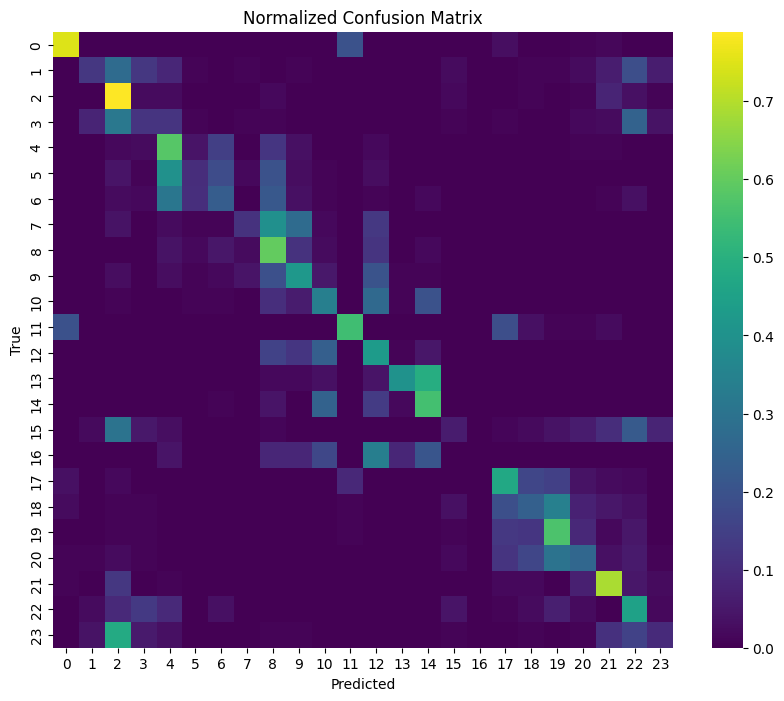


Classification Report:
              precision    recall  f1-score      support
0              0.742424  0.748092  0.745247   131.000000
1              0.432432  0.124031  0.192771   129.000000
2              0.314642  0.789062  0.449889   128.000000
3              0.211268  0.119048  0.152284   126.000000
4              0.325688  0.581967  0.417647   122.000000
5              0.324324  0.099174  0.151899   121.000000
6              0.345238  0.230159  0.276190   126.000000
7              0.538462  0.112000  0.185430   125.000000
8              0.290698  0.600000  0.391645   125.000000
9              0.364964  0.420168  0.390625   119.000000
10             0.327731  0.336207  0.331915   116.000000
11             0.642202  0.546875  0.590717   128.000000
12             0.302857  0.430894  0.355705   123.000000
13             0.877193  0.403226  0.552486   124.000000
14             0.404762  0.552846  0.467354   123.000000
15             0.240000  0.060000  0.096000   100.000000
16     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


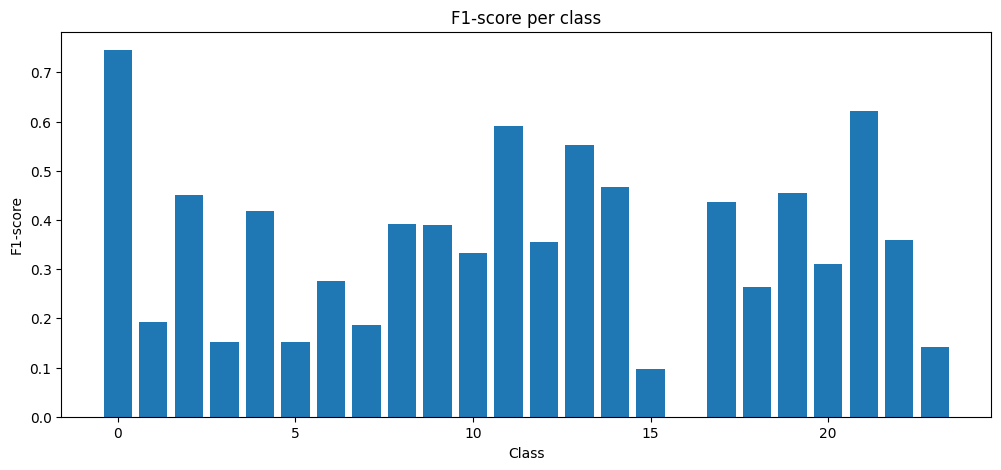

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# -----------------------------
# 1️⃣ Cargar modelo
# -----------------------------
model = tf.keras.models.load_model("/content/drive/MyDrive/TPs PAIByB/FINAL/Modelos_Entrenados/model_resnet2.h5")

# -----------------------------
# 2️⃣ Generador de validación
# -----------------------------
batch_size = 4

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

validation_generator = val_datagen.flow_from_directory(
    '/content/drive/MyDrive/TPs PAIByB/FINAL/aislados_test',
    target_size=(224,224),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False
)

# -----------------------------
# 3️⃣ Predicciones
# -----------------------------
preds = model.predict(validation_generator)
y_pred = np.argmax(preds, axis=1)
y_true = validation_generator.classes

# -----------------------------
# 4️⃣ Accuracy
# -----------------------------
acc = accuracy_score(y_true, y_pred)
print(f"\nAccuracy: {acc:.4f}")

# -----------------------------
# 5️⃣ Matriz de confusión
# -----------------------------
cm = confusion_matrix(y_true, y_pred)

# Normalización por fila (recall)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10,8))
sns.heatmap(cm_norm, cmap="viridis")
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# -----------------------------
# 6️⃣ Classification Report
# -----------------------------
report = classification_report(y_true, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

print("\nClassification Report:")
print(df_report)

# -----------------------------
# 7️⃣ F1-score por clase
# -----------------------------
f1_scores = df_report.iloc[:-3]['f1-score']

plt.figure(figsize=(12,5))
plt.bar(range(len(f1_scores)), f1_scores)
plt.xlabel("Class")
plt.ylabel("F1-score")
plt.title("F1-score per class")
plt.show()

## Métricas del Fine-tuning de VGG16

Found 2873 images belonging to 24 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


719/719 ━━━━━━━━━━━━━━━━━━━━ 2167s 3s/step

Accuracy: 0.8538


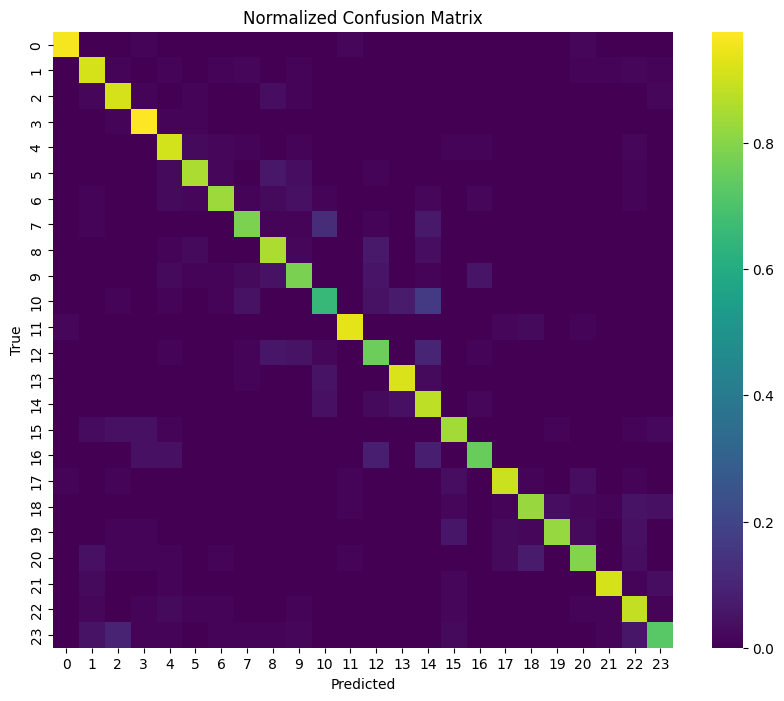


Classification Report:
              precision    recall  f1-score      support
0              0.976744  0.961832  0.969231   131.000000
1              0.836879  0.914729  0.874074   129.000000
2              0.841727  0.914062  0.876404   128.000000
3              0.917910  0.976190  0.946154   126.000000
4              0.834586  0.909836  0.870588   122.000000
5              0.895652  0.851240  0.872881   121.000000
6              0.913043  0.833333  0.871369   126.000000
7              0.867257  0.784000  0.823529   125.000000
8              0.792593  0.856000  0.823077   125.000000
9              0.794872  0.781513  0.788136   119.000000
10             0.723810  0.655172  0.687783   116.000000
11             0.960000  0.937500  0.948617   128.000000
12             0.781513  0.756098  0.768595   123.000000
13             0.897638  0.919355  0.908367   124.000000
14             0.679245  0.878049  0.765957   123.000000
15             0.800000  0.840000  0.819512   100.000000
16     

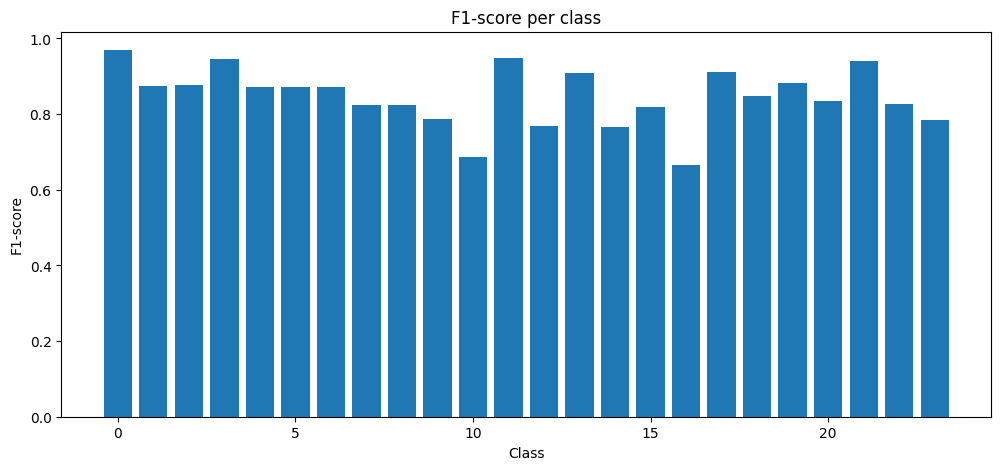

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# 1️⃣ Cargar modelo
# -----------------------------
model = tf.keras.models.load_model("/content/drive/MyDrive/TPs PAIByB/FINAL/Modelos_Entrenados/model_VGG.h5")

# -----------------------------
# 2️⃣ Generador de validación
# -----------------------------
batch_size = 4

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

validation_generator = val_datagen.flow_from_directory(
    '/content/drive/MyDrive/TPs PAIByB/FINAL/aislados_test',
    target_size=(224,224),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False
)

# -----------------------------
# 3️⃣ Predicciones
# -----------------------------
preds = model.predict(validation_generator)
y_pred = np.argmax(preds, axis=1)
y_true = validation_generator.classes

# -----------------------------
# 4️⃣ Accuracy
# -----------------------------
acc = accuracy_score(y_true, y_pred)
print(f"\nAccuracy: {acc:.4f}")

# -----------------------------
# 5️⃣ Matriz de confusión
# -----------------------------
cm = confusion_matrix(y_true, y_pred)

# Normalización por fila (recall)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10,8))
sns.heatmap(cm_norm, cmap="viridis")
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# -----------------------------
# 6️⃣ Classification Report
# -----------------------------
report = classification_report(y_true, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

print("\nClassification Report:")
print(df_report)

# -----------------------------
# 7️⃣ F1-score por clase
# -----------------------------
f1_scores = df_report.iloc[:-3]['f1-score']

plt.figure(figsize=(12,5))
plt.bar(range(len(f1_scores)), f1_scores)
plt.xlabel("Class")
plt.ylabel("F1-score")
plt.title("F1-score per class")
plt.show()


## Comparación de los modelos

La siguiente tabla resume el desempeño de los modelos sobre el conjunto de test (2874 recortes):

| Modelo | Exactitud | F1 macro |
|---|:---:|:---:|
| ResNet50 | ~0.39 | ~0.35 |
| VGG16 (baseline) | 0.85 | 0.85 |
| VGG16 + SE (atención) | 0.86 | 0.86 |
| **VGG16 final** (SE + `class_weight` + *label smoothing* + L2) | **0.87** | **0.86** |

El **modelo final** alcanza una exactitud del **87 %**, superando al *baseline* de VGG16 (85 %) y a la versión con atención sin regularización (86 %). El *backbone* resulta determinante (VGG16 supera ampliamente a ResNet50), mientras que la mayor ganancia sobre VGG16 proviene de la regularización y el balanceo de clases. El error residual se concentra en los **cromosomas pequeños de morfología similar (16 a 22)** y en el **cromosoma Y**, la clase minoritaria.